In [1190]:
import numpy as np
import pandas as pd
from mlxtend.plotting import plot_decision_regions

In [ ]:
class Perceptron():
    def __init__(self, lr: float = 0.01, max_iter: int = 1000,  random_state= None):
        self.weights = None
        self.bias = None
        self.lr = lr
        self.max_iter = max_iter
        self.coef_ = None
        self.intercept_ = None
        if random_state is not None:
            np.random.seed(random_state)


    def find_loss(self, y_true, z):
        """hinge loss function"""
        return max(0, -y_true * z)


    def calc_gradients(self, x, y_true, loss):
        """calculates gradients for x"""
        if loss > 0:
            dw = -y_true * x
            db = -y_true
        else:
            dw = np.zeros_like(x)
            db = 0.0
        return dw, db
    

    def fit(self, x, y):
        """fit training function"""
        x = np.array(x)
        y = np.array(y)
        y = np.where(y == 0, -1, 1)
        n_samples, n_features = x.shape
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0
        indices = np.arange(n_samples)
        for epoch in range(self.max_iter):
            np.random.shuffle(indices)
            mis_classified = 0
            for idx in indices:
                z = np.dot(x[idx], self.weights) + self.bias
                loss = self.find_loss(y[idx], z)
                dw, db = self.calc_gradients(x[idx], y[idx], loss)
                
                # Fixed: Use minus sign for gradient descent
                self.weights -= self.lr * dw
                self.bias -= self.lr * db
                if loss > 0:
                    mis_classified += 1
                
            if mis_classified == 0 or (1 - mis_classified/n_samples) > 0.95:
                print(f"Converged after epoch: {epoch}")
                break
        self.coef_, self.intercept_ = self.weights.flatten(), self.bias
        return self


    def predict(self, x):
        z = np.dot(x, self.weights) + self.bias
        return np.where(z >= 0, 1, 0).flatten() # activation

In [1192]:
df = pd.read_csv('placement.csv')

In [1193]:
df.head()

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1


In [1194]:
x, y = df.iloc[:, :-1], df['placed']

In [1195]:
x.head()

,cgpa,resume_score
0,8.14,6.52
1,6.17,5.17
2,8.27,8.86
3,6.88,7.27
4,7.52,7.30


In [1196]:
y.head()

0    1
1    0
2    1
3    1
4    1
Name: placed, dtype: int64

In [1197]:
pr = Perceptron()

In [1198]:
x, y = np.array(x), np.array(y)

In [1199]:
pr.fit(x, y)

Converged after epoch: 202


In [1200]:
result = pr.predict(x)
print('Actual_label vs Predicted_label:\n')

total = 0
for actual, predicted in zip(y, result):
    if actual == predicted:
        total += 1
        print(f'Correct: {actual} = {predicted}')
    else:
        print(f'Wrong: {actual} != {predicted}')
print(f"\nAccuracy: {total/len(result)}")

Actual_label vs Predicted_label:

Correct: 1 = 1
Correct: 0 = 0
Correct: 1 = 1
Correct: 1 = 1
Correct: 1 = 1
Correct: 1 = 1
Correct: 0 = 0
Wrong: 0 != 1
Correct: 0 = 0
Correct: 1 = 1
Correct: 0 = 0
Correct: 0 = 0
Correct: 0 = 0
Correct: 1 = 1
Correct: 1 = 1
Correct: 1 = 1
Correct: 1 = 1
Correct: 1 = 1
Correct: 0 = 0
Correct: 1 = 1
Correct: 0 = 0
Correct: 0 = 0
Correct: 0 = 0
Correct: 0 = 0
Correct: 1 = 1
Correct: 1 = 1
Correct: 0 = 0
Correct: 0 = 0
Correct: 1 = 1
Correct: 0 = 0
Correct: 1 = 1
Correct: 0 = 0
Correct: 0 = 0
Correct: 1 = 1
Correct: 1 = 1
Correct: 1 = 1
Correct: 1 = 1
Correct: 1 = 1
Correct: 0 = 0
Correct: 1 = 1
Correct: 1 = 1
Correct: 1 = 1
Correct: 1 = 1
Correct: 1 = 1
Correct: 0 = 0
Correct: 1 = 1
Correct: 0 = 0
Correct: 1 = 1
Correct: 0 = 0
Correct: 0 = 0
Correct: 1 = 1
Correct: 0 = 0
Correct: 0 = 0
Correct: 0 = 0
Correct: 0 = 0
Correct: 1 = 1
Correct: 0 = 0
Correct: 0 = 0
Correct: 0 = 0
Correct: 0 = 0
Correct: 0 = 0
Correct: 1 = 1
Correct: 0 = 0
Correct: 1 = 1
Correct

[ 0.58440952 -0.06079714] -3.429999999999971


<Axes: >

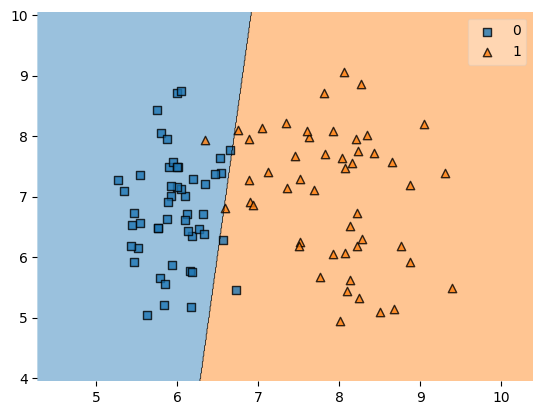

In [1201]:
print(pr.coef_, pr.intercept_)
plot_decision_regions(x, y, clf=pr, )